# 09 · Genomic region complexity

**Question.** How does the performance of the 480 pipeline runs change with the complexity of the genomic region, across the six GIAB GRCh38 union stratifications?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (the variant set of each run), `data/reference/TestCases.csv`, the truth VCF `data/truth/hc_bed_filtered.recode.vcf` and the six stratification BEDs `data/reference/stratification/*.bed.gz`. It never reads `data/raw/`; no run VCF is parsed.

**Regions.** Segmental duplications; the regions outside them; all low-mappability and segmental duplication regions; the regions outside them; all difficult regions; the regions outside them.

**Metrics.** For a region R, the pipeline set and the high-confidence set are filtered with the same BED: a variant is kept if it lies in a BED interval **on its own chromosome** with start <= POS < end. With P_R the filtered pipeline set and H_R the filtered high-confidence set: TP = |P_R and H_R|, precision = TP / |P_R|, recall = TP / |H_R| and F1 their harmonic mean. Precision and F1 are left blank for a run with no calls in R.

**Not the legacy metric (D9).** Legacy scored the region-filtered pipeline set against the whole truth set, so its recall fell with the size of the region. This notebook filters both sets, as the manuscript text describes, so recall is measured against the truth variants inside the region. Notebook 07 keeps the legacy definition for parity. The boundary is still the legacy `start <= POS < end` (D2, undecided), and the filter is the chromosome-aware one (D1).

**SomaticSniper asymmetry.** SomaticSniper VCFs have `FILTER = .` on every record, so the PASS filter is not applied to them (legacy behaviour); Mutect and Strelka are PASS-filtered. The metrics of SomaticSniper runs inherit this.

**Produces** (`results/09_region_complexity/`):
- `tables/region_truth.csv`: the truth variants in each region, and how many the chromosome-blind legacy filter would keep.
- `tables/region_metrics.csv`: for each run and region, the calls kept, the truth variants kept, TP, precision, recall and F1.
- `tables/region_summary.csv`: for each region, the median, quartiles, minimum and maximum of each metric, and the runs with no calls.
- `figures/region_metrics`: box plots of precision, recall and F1 per region.

**Parity.** No legacy table holds these metrics. Parity checks the values in the manuscript text: the truth variants per region (38, 1,123, 43, 1,118, 294, 867) and their shares (25.3%, 3.7% and 3.3%), the median F1 outside difficult regions (0.760) and the medians below 0.5 in the most complex regions. The one statement that needs a reading (median F1 "below 0.5 in difficult regions") is reported as it comes out.

**Does not.** Change the boundary convention, or repeat the analysis with the legacy metric (notebook 07).

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("09_region_complexity")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
REGIONS = [region for region, _, _ in viz.REGIONS]
LABELS = {region: label for region, label, _ in viz.REGIONS}
# Values in the manuscript text (given by the author)
MANUSCRIPT_TRUTH = {"GRCh38_segdups": 38, "GRCh38_notinsegdups": 1123, "GRCh38_alllowmapandsegdupregions": 43,
                    "GRCh38_notinalllowmapandsegdupregions": 1118, "GRCh38_alldifficultregions": 294,
                    "GRCh38_notinalldifficultregions": 867}
MANUSCRIPT_SHARES = {"GRCh38_alldifficultregions": 25.3, "GRCh38_alllowmapandsegdupregions": 3.7, "GRCh38_segdups": 3.3}
MANUSCRIPT_MEDIAN_F1_EASY = 0.760   # outside all difficult regions

## Load + validate

In [3]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)

meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME)
assert len(runs) == EXPECTED_RUNS, len(runs)

truth = io.truth_set(str(config.TRUTH_VCF))
assert len(truth) > 0

assert sorted(p.name for p in config.STRATIFICATION_DIR.glob("*.bed.gz")) == sorted(r + ".bed.gz" for r in REGIONS)
beds = {}
for region in REGIONS:
    bed = io.read_bed(str(config.STRATIFICATION_DIR / (region + ".bed.gz")))
    assert bed[["start", "end"]].notna().all().all() and (bed["start"] < bed["end"]).all(), region
    beds[region] = io.BedRegions(bed)
print("{} runs, {} truth variants, {} regions".format(len(runs), len(truth), len(beds)))

480 runs, 1161 truth variants, 6 regions


## Analysis

In [4]:
truth_in = {region: io.filter_variants_by_bed(truth, beds[region]) for region in REGIONS}
truth_blind = {region: len(io.filter_variants_by_bed(truth, beds[region], chromosome_aware=False)) for region in REGIONS}
for inside, outside in zip(REGIONS[0::2], REGIONS[1::2]):  # each region and its complement partition the truth set
    assert not (truth_in[inside] & truth_in[outside]) and (truth_in[inside] | truth_in[outside]) == truth, (inside, outside)
region_truth = pd.DataFrame([(r, LABELS[r], len(truth_in[r]), len(truth_in[r]) / len(truth), truth_blind[r]) for r in REGIONS],
                            columns=["region", "label", "n_truth", "fraction_of_truth", "n_truth_chromosome_blind"])
region_truth

,region,label,n_truth,fraction_of_truth,n_truth_chromosome_blind
0,GRCh38_segdups,Segmental duplications,38,0.032730,685
1,GRCh38_notinsegdups,Outside segmental duplications,1123,0.967270,1161
2,GRCh38_alllowmapandsegdupregions,Low mappability and segmental duplications,43,0.037037,859
3,GRCh38_notinalllowmapandsegdupregions,Outside low mappability and segmental duplicat...,1118,0.962963,1161
4,GRCh38_alldifficultregions,All difficult regions,294,0.253230,1058
5,GRCh38_notinalldifficultregions,Outside all difficult regions,867,0.746770,1156


In [5]:
rows = []
for run, key in zip(runs.index, runs["TestCaseNo"]):
    for region in REGIONS:
        called = io.filter_variants_by_bed(sets[key], beds[region])
        rows.append((run, region) + metrics.region_scores(called, truth_in[region]))
region_metrics = pd.DataFrame(rows, columns=["run", "region", "n_called", "n_truth", "tp", "precision", "recall", "f1"])
assert len(region_metrics) == EXPECTED_RUNS * len(REGIONS) and region_metrics["recall"].notna().all()
assert (region_metrics["n_truth"] == region_metrics["region"].map(lambda r: len(truth_in[r]))).all()
assert (region_metrics["tp"] <= region_metrics[["n_called", "n_truth"]].min(axis=1)).all()
region_metrics.head()

,run,region,n_called,n_truth,tp,precision,recall,f1
0,2,GRCh38_segdups,42,38,31,0.738095,0.815789,0.775000
1,2,GRCh38_notinsegdups,1219,1123,1005,0.824446,0.894924,0.858241
2,2,GRCh38_alllowmapandsegdupregions,47,43,36,0.765957,0.837209,0.800000
3,2,GRCh38_notinalllowmapandsegdupregions,1214,1118,1000,0.823723,0.894454,0.857633
4,2,GRCh38_alldifficultregions,324,294,254,0.783951,0.863946,0.822006


In [6]:
summary_rows = []
for region in REGIONS:
    part = region_metrics[region_metrics["region"] == region]
    row = {"region": region, "label": LABELS[region], "n_truth": len(truth_in[region]), "n_runs": len(part),
           "n_runs_without_calls": int((part["n_called"] == 0).sum())}
    for metric in ("precision", "recall", "f1"):
        values = part[metric].dropna()
        row.update({metric + "_median": values.median(), metric + "_q1": values.quantile(0.25),
                    metric + "_q3": values.quantile(0.75), metric + "_min": values.min(), metric + "_max": values.max()})
    summary_rows.append(row)
region_summary = pd.DataFrame(summary_rows)
region_summary[["label", "n_truth", "n_runs_without_calls", "precision_median", "recall_median", "f1_median"]].round(3)

,label,n_truth,n_runs_without_calls,precision_median,recall_median,f1_median
0,Segmental duplications,38,4,0.571,0.645,0.491
1,Outside segmental duplications,1123,0,0.682,0.791,0.709
2,Low mappability and segmental duplications,43,4,0.571,0.651,0.472
3,Outside low mappability and segmental duplicat...,1118,0,0.682,0.792,0.710
4,All difficult regions,294,0,0.601,0.748,0.642
5,Outside all difficult regions,867,0,0.754,0.793,0.760


## Save tables

Written to staging; moved to `results/09_region_complexity/` only if parity passes.

In [7]:
io.write_csv(region_truth, STAGE.path(OUT / "tables" / "region_truth.csv"), sort_by="region")
io.write_csv(region_metrics, STAGE.path(OUT / "tables" / "region_metrics.csv"), sort_by=["run", "region"])
io.write_csv(region_summary, STAGE.path(OUT / "tables" / "region_summary.csv"), sort_by="region")

## Figures

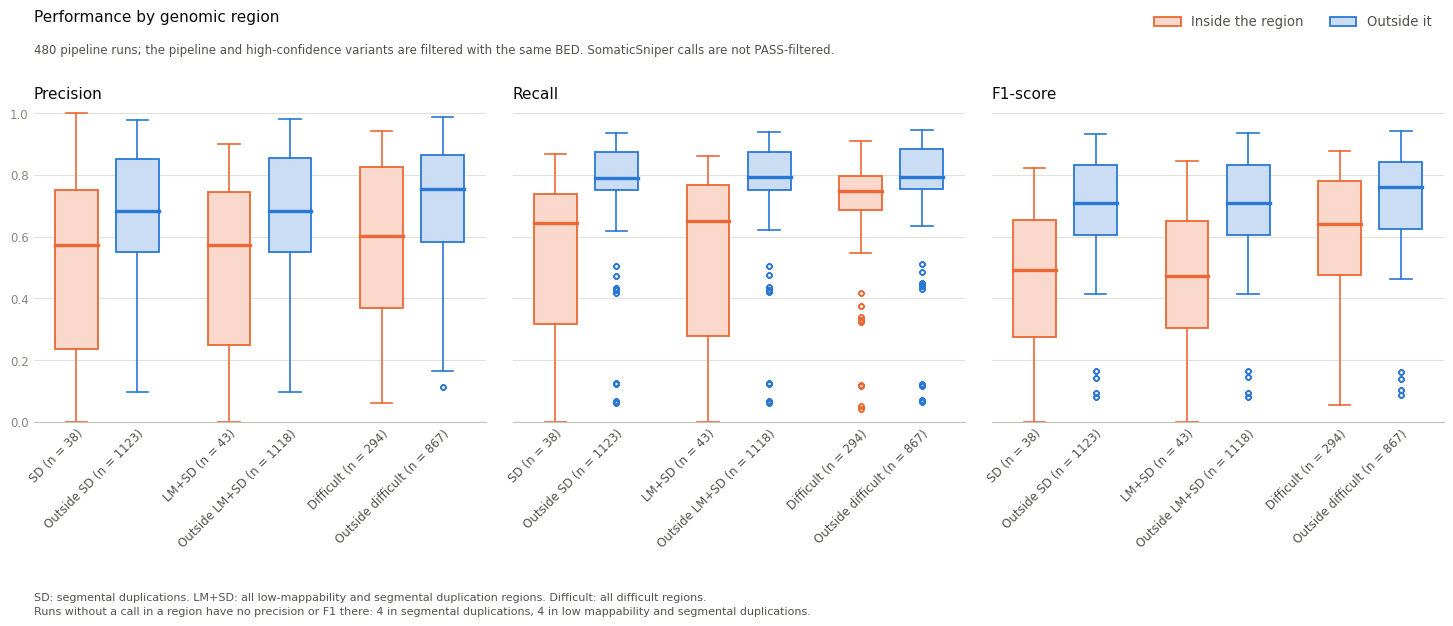

In [8]:
fig, axes = viz.region_boxplots(
    region_metrics, dict(zip(region_truth["region"], region_truth["n_truth"])),
    title="Performance by genomic region",
    subtitle="480 pipeline runs; the pipeline and high-confidence variants are filtered with the same BED. SomaticSniper calls are not PASS-filtered.",
    footnote="SD: segmental duplications. LM+SD: all low-mappability and segmental duplication regions. Difficult: all difficult regions.\n"
             "Runs without a call in a region have no precision or F1 there: {}.".format(
        ", ".join("{} in {}".format(int(r.n_runs_without_calls), r.label.lower())
                  for r in region_summary.itertuples() if r.n_runs_without_calls) or "none"))
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "region_metrics"))
plt.show()

## Parity check

Against the values in the manuscript text: each region's truth variants, the shares of the truth set in the three complex regions, the median F1 outside all difficult regions, and the medians below 0.5. What does not come out as the text reads is listed as such. Results are moved out of staging only if every check that ran passes.

In [9]:
parity = audit.Parity()
ours = dict(zip(region_truth["region"], region_truth["n_truth"]))
parity.check("truth variants per region == manuscript (38, 1,123, 43, 1,118, 294, 867)", ours == MANUSCRIPT_TRUTH,
             ", ".join("{} {}".format(LABELS[r].lower(), ours[r]) for r in REGIONS))
shares = {r: round(100 * ours[r] / len(truth), 1) for r in MANUSCRIPT_SHARES}
parity.check("shares of the {} truth variants in difficult, low-mappability and segmental duplication regions == 25.3%, 3.7%, 3.3%".format(len(truth)),
             shares == MANUSCRIPT_SHARES, ", ".join("{} {}%".format(LABELS[r].lower(), v) for r, v in shares.items()))
median_f1 = dict(zip(region_summary["region"], region_summary["f1_median"]))
parity.check("median F1 outside all difficult regions == {}".format(MANUSCRIPT_MEDIAN_F1_EASY),
             round(median_f1["GRCh38_notinalldifficultregions"], 3) == MANUSCRIPT_MEDIAN_F1_EASY,
             "{:.4f}".format(median_f1["GRCh38_notinalldifficultregions"]))
parity.check("median F1 below 0.5 in segmental duplications and in low-mappability and segmental duplication regions",
             median_f1["GRCh38_segdups"] < 0.5 and median_f1["GRCh38_alllowmapandsegdupregions"] < 0.5,
             "{:.3f} and {:.3f}".format(median_f1["GRCh38_segdups"], median_f1["GRCh38_alllowmapandsegdupregions"]))
parity.skip("median F1 below 0.5 in all difficult regions (the text says 'difficult regions')",
            "NOT REPRODUCED for the stratification 'all difficult regions': its median is {:.3f}; the two most complex categories are below 0.5".format(
                median_f1["GRCh38_alldifficultregions"]))
parity.skip("region_metrics.csv, region_summary.csv and the figure",
            "no legacy table holds these metrics: legacy scored region-filtered calls against the whole truth set (D9)")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (4 checks, 2 skipped)
PASS  truth variants per region == manuscript (38, 1,123, 43, 1,118, 294, 867)  [segmental duplications 38, outside segmental duplications 1123, low mappability and segmental duplications 43, outside low mappability and segmental duplications 1118, all difficult regions 294, outside all difficult regions 867]
PASS  shares of the 1161 truth variants in difficult, low-mappability and segmental duplication regions == 25.3%, 3.7%, 3.3%  [all difficult regions 25.3%, low mappability and segmental duplications 3.7%, segmental duplications 3.3%]
PASS  median F1 outside all difficult regions == 0.76  [0.7599]
PASS  median F1 below 0.5 in segmental duplications and in low-mappability and segmental duplication regions  [0.491 and 0.472]
SKIP  median F1 below 0.5 in all difficult regions (the text says 'difficult regions')  [NOT REPRODUCED for the stratification 'all difficult regions': its median is 0.642; the two most complex categories are below 0.5]
SKIP  re

## Audit summary

In [10]:
def iqr(region, metric):
    row = region_summary[region_summary["region"] == region].iloc[0]
    return row[metric + "_q3"] - row[metric + "_q1"]


pairs = list(zip(REGIONS[0::2], REGIONS[1::2]))
lines = [
    "runs: {}; regions: {}; truth variants: {}; regions filtered with start <= POS < end on the variant's own chromosome".format(
        len(runs), len(REGIONS), len(truth)),
    "",
    "truth variants in each region (chromosome-aware filter; the chromosome-blind legacy filter, D1, would keep):",
] + ["  {}: {} ({:.1f}%); chromosome-blind {}".format(r.label, r.n_truth, 100 * r.fraction_of_truth, r.n_truth_chromosome_blind)
     for r in region_truth.itertuples()] + [
    "",
    "median precision, recall and F1 per region:",
] + ["  {}: {:.3f}, {:.3f}, {:.3f}".format(r.label, r.precision_median, r.recall_median, r.f1_median)
     for r in region_summary.itertuples()] + [
    "",
    "interquartile range of precision, inside the region against outside it: " + "; ".join(
        "{} {:.3f} vs {:.3f}".format(LABELS[a].lower(), iqr(a, "precision"), iqr(b, "precision")) for a, b in pairs),
    "runs with no call in a region (precision and F1 left blank): " + (", ".join(
        "{} in {}".format(int(r.n_runs_without_calls), r.label.lower()) for r in region_summary.itertuples() if r.n_runs_without_calls) or "none"),
    "",
    "against the manuscript text: the six truth counts, the three shares, the median F1 of {} outside difficult regions and the medians below 0.5 in the two most complex categories are reproduced".format(
        MANUSCRIPT_MEDIAN_F1_EASY),
    "  the text's 'below 0.5 in difficult regions' holds for segmental duplications and for low-mappability plus segmental duplication regions, not for 'all difficult regions' ({:.3f})".format(
        median_f1["GRCh38_alldifficultregions"]),
    "the metric differs from legacy (D9): recall is TP / truth variants in the region, not TP / all truth variants",
    "SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved); its metrics inherit this",
    "not compared with legacy: region_metrics.csv, region_summary.csv, the figure",
    "",
    "python {} | pandas {} | numpy {}".format(sys.version.split()[0], pd.__version__, np.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; regions: 6; truth variants: 1161; regions filtered with start <= POS < end on the variant's own chromosome

truth variants in each region (chromosome-aware filter; the chromosome-blind legacy filter, D1, would keep):
  Segmental duplications: 38 (3.3%); chromosome-blind 685
  Outside segmental duplications: 1123 (96.7%); chromosome-blind 1161
  Low mappability and segmental duplications: 43 (3.7%); chromosome-blind 859
  Outside low mappability and segmental duplications: 1118 (96.3%); chromosome-blind 1161
  All difficult regions: 294 (25.3%); chromosome-blind 1058
  Outside all difficult regions: 867 (74.7%); chromosome-blind 1156

median precision, recall and F1 per region:
  Segmental duplications: 0.571, 0.645, 0.491
  Outside segmental duplications: 0.682, 0.791, 0.709
  Low mappability and segmental duplications: 0.571, 0.651, 0.472
  Outside low mappability and segmental duplications: 0.682, 0.792, 0.710
  All difficult regions: 0.601, 0.748, 0.642
  Outside all diff